In [5]:
import os
from pathlib import Path
import numpy as np
import torch
import torch.nn.functional as F
from PIL import Image
from tqdm.auto import tqdm
from transformers import AutoProcessor, AutoModel

In [6]:
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(device)

mps


In [7]:
import os
import torch

os.environ["HF_HOME"] = "models"

import open_clip
model, preprocess_train, preprocess_val = open_clip.create_model_and_transforms('hf-hub:Marqo/marqo-fashionSigLIP')
tokenizer = open_clip.get_tokenizer('hf-hub:Marqo/marqo-fashionSigLIP')
model.to(device)
model.eval()

CustomTextCLIP(
  (visual): TimmModel(
    (trunk): VisionTransformer(
      (patch_embed): PatchEmbed(
        (proj): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
        (norm): Identity()
      )
      (pos_drop): Dropout(p=0.0, inplace=False)
      (patch_drop): Identity()
      (norm_pre): Identity()
      (blocks): Sequential(
        (0): Block(
          (norm1): LayerNorm((768,), eps=1e-06, elementwise_affine=True, bias=True)
          (attn): Attention(
            (qkv): Linear(in_features=768, out_features=2304, bias=True)
            (q_norm): Identity()
            (k_norm): Identity()
            (attn_drop): Dropout(p=0.0, inplace=False)
            (norm): Identity()
            (proj): Linear(in_features=768, out_features=768, bias=True)
            (proj_drop): Dropout(p=0.0, inplace=False)
          )
          (ls1): Identity()
          (drop_path1): Identity()
          (norm2): LayerNorm((768,), eps=1e-06, elementwise_affine=True, bias=True)
          

In [8]:
dataset_dir = Path("../dataset/images")
EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

image_paths = sorted([
    p for p in dataset_dir.iterdir()
    if p.suffix.lower() in EXTENSIONS
])
print(f"Found {len(image_paths)} images")

Found 3200 images


In [9]:
from torch.utils.data import Dataset

class ImageDataset(Dataset):
    def __init__(self, image_paths):
        self.image_paths = image_paths
    def __len__(self):
        return len(self.image_paths)
    def __getitem__(self, idx):
        image = Image.open(self.image_paths[idx]).convert("RGB")
        return image, str(self.image_paths[idx])

In [10]:
from torch.utils.data import DataLoader
import torch

dataset = ImageDataset(image_paths)

def collate_fn(batch):
    images, paths = zip(*batch)

    images = torch.stack([
        preprocess_val(img) for img in images
    ])

    return images, list(paths)

loader = DataLoader(
    dataset,
    batch_size=32,
    shuffle=False,
    num_workers=0,
    collate_fn=collate_fn,
    pin_memory=True,
)

In [11]:
all_embeddings = []
all_paths = []

model.eval()

with torch.no_grad(), torch.cuda.amp.autocast():
    for images, paths in tqdm(loader):
        images = images.to(device)

        embeddings = model.encode_image(
            images,
            normalize=True
        )

        all_embeddings.append(embeddings.cpu())
        all_paths.extend(paths)

all_embeddings = torch.cat(all_embeddings, dim=0)

/var/folders/s4/qdcpbr7x4g9b_ky642x9nq180000gn/T/ipykernel_30828/1613972115.py:6: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.no_grad(), torch.cuda.amp.autocast():
/Users/armaanjagirdar/glance_task/env2/lib/python3.12/site-packages/torch/cuda/amp/autocast_mode.py:54: UserWarning: CUDA is not available or torch_xla is imported. Disabling autocast.
  super().__init__(
  0%|          | 0/100 [00:00<?, ?it/s]/Users/armaanjagirdar/glance_task/env2/lib/python3.12/site-packages/torch/utils/data/dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
100%|██████████| 100/100 [01:09<00:00,  1.43it/s]


In [12]:
image_embeddings = all_embeddings
print(image_embeddings.shape)

norms = torch.norm(image_embeddings, dim=1)
print(norms.min())
print(norms.max())
print(norms.mean())

torch.Size([3200, 768])
tensor(1.0000)
tensor(1.0000)
tensor(1.)


In [13]:
import hnswlib
import numpy as np

embeddings = image_embeddings.cpu().numpy().astype(np.float32)

dimension = embeddings.shape[1]
num_elements = embeddings.shape[0]

index = hnswlib.Index(
    space="cosine",
    dim=dimension
)

index.init_index(
    max_elements=num_elements,
    ef_construction=200,
    M=16
)

index.add_items(
    embeddings,
    np.arange(num_elements)
)

index.set_ef(50)

print(f"Indexed {num_elements} images.")

Indexed 3200 images.


In [14]:
index.save_index("../vdb/siglip2_hnsw.bin")

In [15]:
index = hnswlib.Index(space="cosine", dim=512)
index.load_index("../vdb/siglip2_hnsw.bin")

In [16]:
@torch.no_grad()
def encode_text(text):
    tokens = tokenizer([text]).to(device)
    embedding = model.encode_text(
        tokens,
        normalize=True
    )
    return embedding.cpu().numpy().astype(np.float32)
    
query_embedding = encode_text("red dress")
query_embedding.shape

(1, 768)

In [17]:
def retrieve(query, k=10):
    query_embedding = encode_text(query).astype(np.float32)
    indices, distances = index.knn_query(
        query_embedding,
        k=k
    )

    results = []
    for idx, dist in zip(indices[0], distances[0]):

        results.append({
            "path": all_paths[idx],
            "score": float(1 - dist)  
        })

    return results

In [18]:
import matplotlib.pyplot as plt

def show_results(results):
    n = len(results)
    fig, axes = plt.subplots(1, n, figsize=(4*n, 4))
    if n == 1:
        axes = [axes]
    for ax, r in zip(axes, results):
        img = Image.open(r["path"]).convert("RGB")
        ax.imshow(img)
        ax.set_title(f"{r['score']:.3f}")
        ax.axis("off")

    plt.tight_layout()
    plt.show()
    plt.close(fig)

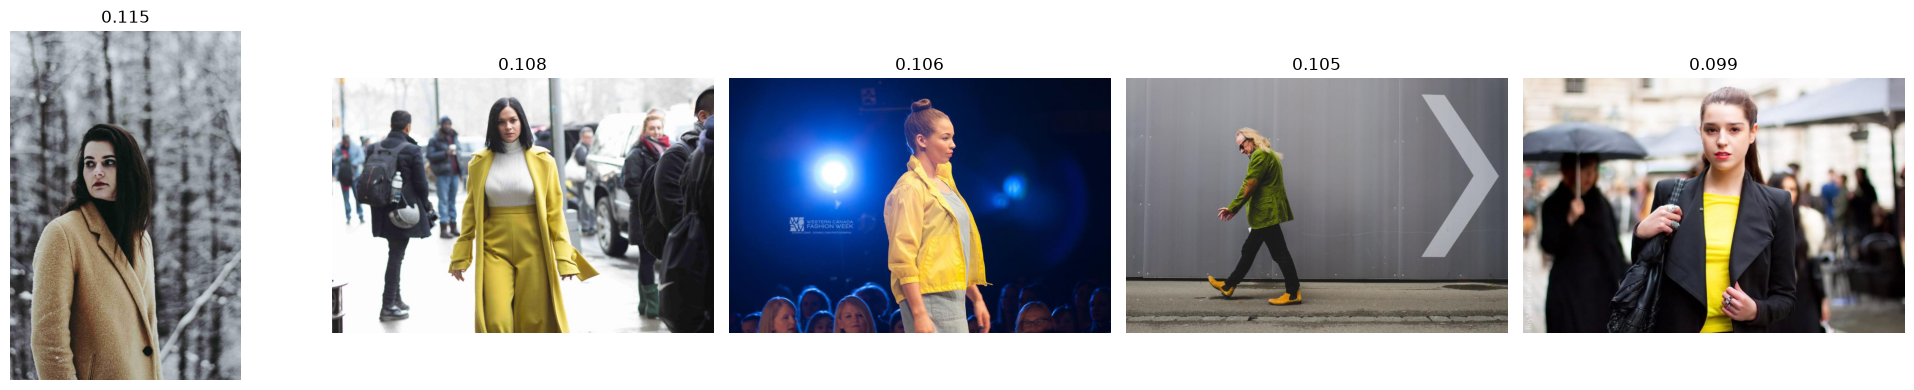

In [19]:
show_results(retrieve("A person in a bright yellow raincoat.", 5))

In [20]:
checkpoint = torch.load("best_siglip_lora.pt")

model.load_state_dict(
    checkpoint["adapter"],
    strict=False,
)

metrics = evaluate(
    model,
    test_loader,
)

print(metrics)

FileNotFoundError: [Errno 2] No such file or directory: 'best_siglip_lora.pt'